In [2]:
import numpy as np
import scanpy as sc
import squidpy as sq
import stan


In [17]:
adata=sc.read_h5ad("data/Wu2021/st_CID4535.h5ad")
sc.pp.filter_genes(adata, min_cells=adata.n_obs/5)
sc.pp.normalize_total(adata)
adata.X=np.sqrt(adata.X)
sc.pp.scale(adata)

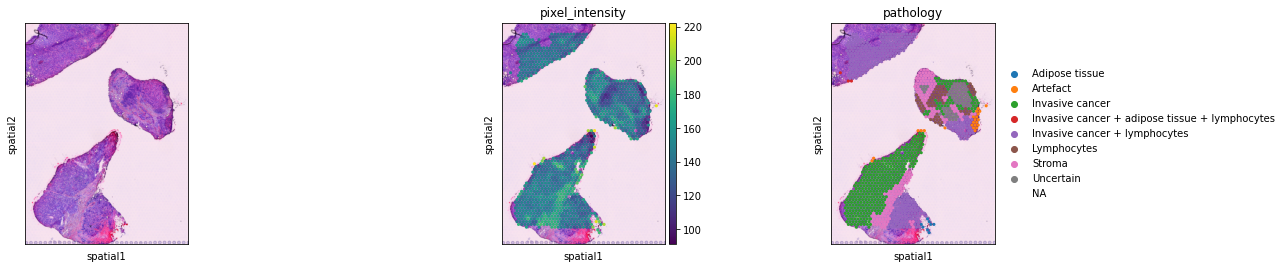

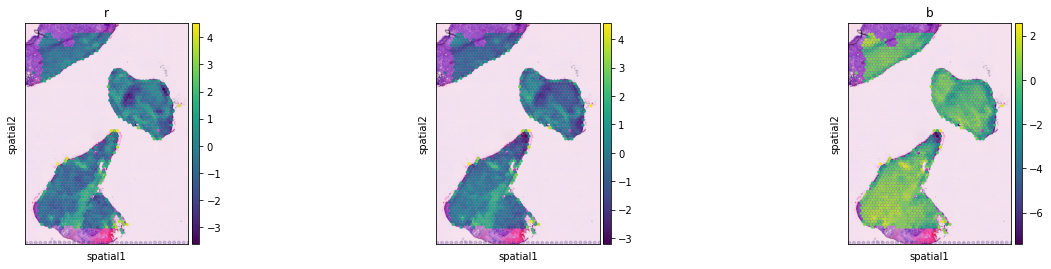

In [21]:
stan.pp.pixel_intensity(adata, window_size=15)
sc.pl.spatial(adata, color=[None, "pixel_intensity", 'pathology'], size=1.5)
sc.pl.spatial(sq.pl.extract(adata, obsm_key='pixel_intensity'), color=["r", "g", "b"], size=1.5)

In [22]:
genes_to_plot=adata.var.sort_values(by="std", ascending=False).head(16).index

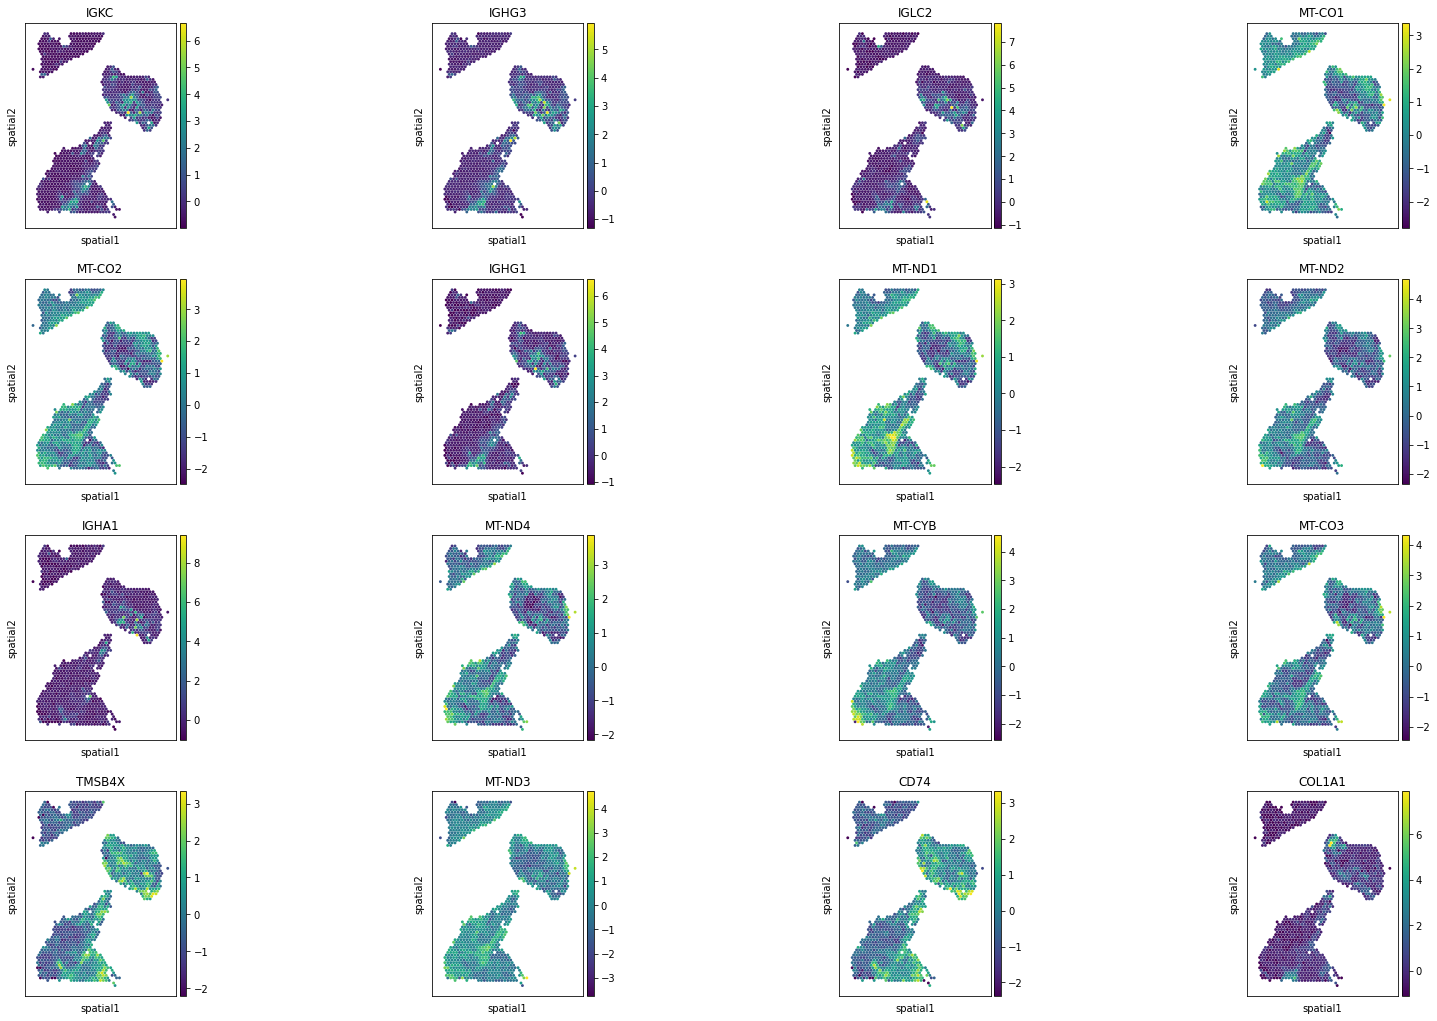

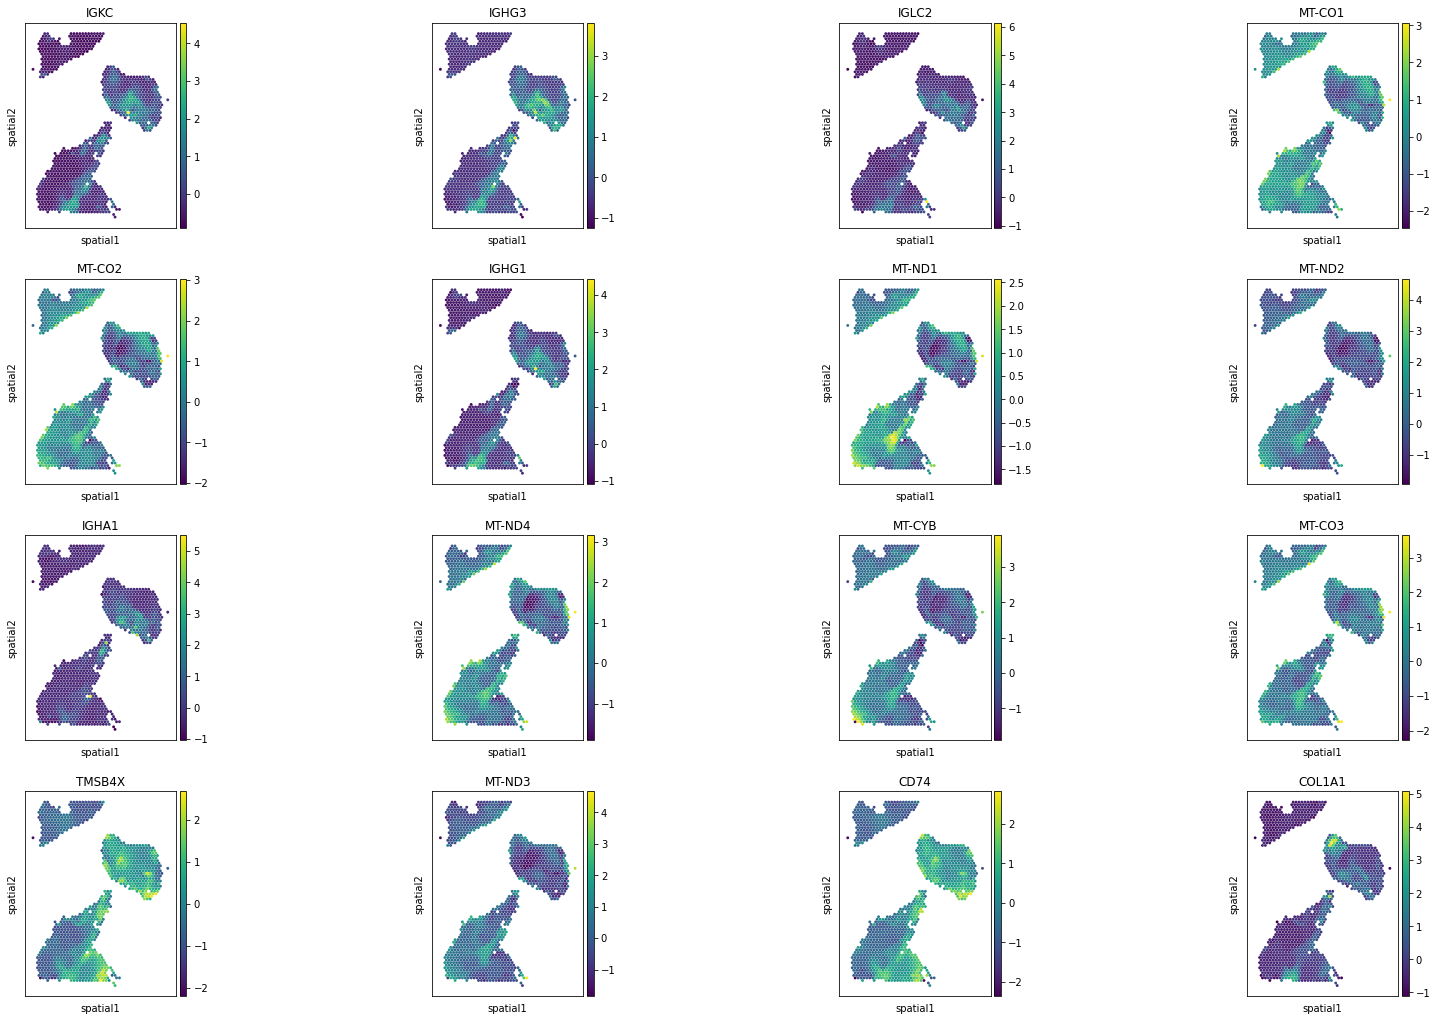

In [23]:
stan.pp.make_kernel(adata, n=10, im_feats_weight=0.2, banwidth=0.1)

adata.layers['spatial']=stan.pp.kernel_smooth(adata.to_df(), adata.obsp['kernel'])

sc.pl.spatial(adata, color=genes_to_plot, alpha_img=0, size=1.5)
sc.pl.spatial(adata, color=genes_to_plot, layer='spatial', alpha_img=0, size=1.5)

adata.var['spat_cor']=np.diag(adata.to_df('spatial').T.dot(adata.to_df())/adata.n_obs)

adata.to_df('spatial')

In [ ]:
stan.pp.make_kernel(adata, n=500,im_feats_weight=0.15, banwidth=0.25)

Y=adata.to_df()
X=adata.obsm['kernel']

s=((X**2).sum(axis=0))
kernel_proj=X.dot(np.diag(s/(s**2 + 0)).dot(X.T))

adata.layers['spatial']=kernel_proj.dot(Y)
x=adata.layers['spatial'].T
x=(x-x.mean(axis=1).reshape(-1,1))/x.std(axis=1).reshape(-1,1)
adata.layers['spatial']=x.T

adata.var['approx_kernel_spat_cor']=np.diag(adata.to_df('spatial').T.dot(adata.to_df())/adata.n_obs)

sc.pl.spatial(adata, color=["IGKC", 'C3', "GATA3", "PRDX4"], alpha_img=0, size=1.5)
sc.pl.spatial(adata, color=["IGKC", 'C3', "GATA3", "PRDX4"], layer='spatial', alpha_img=0, size=1.5)

print(adata.var['approx_kernel_spat_cor'].median())

kernel_proj=X.dot(np.diag(s/(s**2 + 100)).dot(X.T))

adata.var['approx_kernel_spat_cor']=np.diag(adata.to_df('spatial').T.dot(adata.to_df())/adata.n_obs)

sc.pl.spatial(adata, color=["IGKC", 'C3', "GATA3", "PRDX4"], layer='spatial', alpha_img=0, size=1.5)

adata.var['approx_kernel_spat_cor'].median()